<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-sugar-consumption-trends-ml-59-35?scriptVersionId=232797963" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-sugar-consumption-trends-19602023/sugar_consumption_dataset.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Title: Global Sugar Consumption Trends

#### Description:
Explore worldwide patterns in sugar consumption, highlighting regional differences, historical trends, and health implications.

## Import dataset

In [3]:
df = pd.read_csv('/kaggle/input/global-sugar-consumption-trends-19602023/sugar_consumption_dataset.csv')

In [4]:
df.head()

,Country,Year,Country_Code,Continent,Region,Population,GDP_Per_Capita,Per_Capita_Sugar_Consumption,Total_Sugar_Consumption,Sugar_From_Sugarcane,...,Obesity_Rate,Sugar_Imports,Sugar_Exports,Avg_Retail_Price_Per_Kg,Gov_Tax,Gov_Subsidies,Education_Campaign,Urbanization_Rate,Climate_Conditions,Sugarcane_Production_Yield
0,France,1972,FRA,Europe,Western Europe,2.617306e+08,8692.631696,12.827741,3.357413e+06,68.422963,...,34.094017,5.401670e+06,2.358929e+06,3.864020,0.0,0,0.0,34.503398,3,52.433972
1,Australia,2003,AUS,Oceania,Australia & New Zealand,1.737965e+08,6859.195960,21.362632,3.712750e+06,55.432564,...,16.040118,3.418790e+06,9.694348e+06,3.282101,0.0,0,0.0,31.783067,4,58.382055
2,Germany,1963,DEU,Europe,Western Europe,1.236366e+08,22075.950575,32.077485,3.965951e+06,86.466120,...,14.405741,8.987281e+06,5.451632e+06,1.097687,0.0,0,0.0,51.551345,1,32.184735
3,France,1965,FRA,Europe,Western Europe,2.989961e+08,3728.027392,47.648930,1.424685e+07,69.806707,...,38.499271,5.179004e+06,8.048500e+06,2.761297,0.0,0,0.0,80.386281,2,84.296019
4,Germany,2010,DEU,Europe,Western Europe,7.341531e+06,40420.973962,23.214343,1.704288e+05,63.772278,...,36.190977,6.463439e+06,7.062910e+06,4.219431,0.0,0,1.0,49.701153,3,66.110815


In [5]:
df.tail()

,Country,Year,Country_Code,Continent,Region,Population,GDP_Per_Capita,Per_Capita_Sugar_Consumption,Total_Sugar_Consumption,Sugar_From_Sugarcane,...,Obesity_Rate,Sugar_Imports,Sugar_Exports,Avg_Retail_Price_Per_Kg,Gov_Tax,Gov_Subsidies,Education_Campaign,Urbanization_Rate,Climate_Conditions,Sugarcane_Production_Yield
9995,Japan,2013,JPN,Asia,East Asia,1.577296e+08,13292.772553,52.082820,8.215000e+06,68.735289,...,23.261105,6.789191e+06,1.760144e+06,0.546087,0.0,0,1.0,70.297948,5,50.874135
9996,Japan,1997,JPN,Asia,East Asia,8.194828e+07,15062.553443,59.947295,4.912577e+06,89.760649,...,38.510142,2.945742e+06,9.403225e+06,0.719054,0.0,1,1.0,82.951511,5,49.170137
9997,China,1968,CHN,Asia,East Asia,2.211798e+08,44077.744031,21.447386,4.743729e+06,60.228450,...,31.494902,6.562415e+06,6.828324e+06,3.786874,0.0,0,0.0,80.478768,5,56.414707
9998,France,2020,FRA,Europe,Western Europe,1.089609e+08,19327.592671,35.558519,3.874488e+06,89.151300,...,22.046038,2.736993e+06,1.877796e+06,4.711171,0.0,1,0.0,50.138593,4,44.818364
9999,China,1990,CHN,Asia,East Asia,2.118221e+07,28039.986398,67.470909,1.429183e+06,64.568766,...,21.302099,7.195694e+06,1.698358e+06,1.088151,0.0,0,0.0,39.748626,1,58.549719


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       10000 non-null  object 
 1   Year                          10000 non-null  int64  
 2   Country_Code                  10000 non-null  object 
 3   Continent                     10000 non-null  object 
 4   Region                        10000 non-null  object 
 5   Population                    10000 non-null  float64
 6   GDP_Per_Capita                10000 non-null  float64
 7   Per_Capita_Sugar_Consumption  10000 non-null  float64
 8   Total_Sugar_Consumption       10000 non-null  float64
 9   Sugar_From_Sugarcane          10000 non-null  float64
 10  Sugar_From_Beet               10000 non-null  float64
 11  Sugar_From_HFCS               10000 non-null  float64
 12  Sugar_From_Other              10000 non-null  float64
 13  Pr

In [7]:
df.describe()

,Year,Population,GDP_Per_Capita,Per_Capita_Sugar_Consumption,Total_Sugar_Consumption,Sugar_From_Sugarcane,Sugar_From_Beet,Sugar_From_HFCS,Sugar_From_Other,Processed_Food_Consumption,...,Obesity_Rate,Sugar_Imports,Sugar_Exports,Avg_Retail_Price_Per_Kg,Gov_Tax,Gov_Subsidies,Education_Campaign,Urbanization_Rate,Climate_Conditions,Sugarcane_Production_Yield
count,10000.000000,1.000000e+04,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,1.000000e+04,1.000000e+04,10000.000000,9469.000000,10000.000000,9480.000000,10000.000000,10000.000000,10000.000000
mean,1991.330300,1.501189e+08,25242.491756,37.626027,5.650157e+06,70.028543,22.494559,29.811113,-22.334215,155.294166,...,22.355718,5.040963e+06,5.077761e+06,2.747125,0.150914,0.297500,0.406962,49.973144,2.977100,65.251931
std,18.424086,8.646170e+07,14193.053646,18.733654,4.599203e+06,11.481251,10.207287,17.242892,22.988417,83.677159,...,10.090557,2.890586e+06,2.886414e+06,1.302997,0.357983,0.457181,0.491294,23.185861,1.415831,20.185192
min,1960.000000,1.005004e+06,500.417394,5.017558,7.387572e+03,50.005200,5.003532,0.001761,-84.188301,10.028391,...,5.001991,3.658518e+02,1.577075e+02,0.500030,0.000000,0.000000,0.000000,10.018786,1.000000,30.002468
25%,1976.000000,7.434980e+07,13219.345523,21.386174,1.882590e+06,60.072363,13.544087,14.746013,-38.633165,81.785601,...,13.698372,2.509690e+06,2.570209e+06,1.620856,0.000000,0.000000,0.000000,29.374395,2.000000,47.375830
50%,1991.000000,1.500741e+08,25155.568950,37.878147,4.369083e+06,70.167342,22.532868,30.101299,-22.413240,155.910019,...,22.258420,5.064198e+06,5.103455e+06,2.736859,0.000000,0.000000,0.000000,50.201101,3.000000,65.571891
75%,2007.000000,2.250870e+08,37558.130715,54.003484,8.484738e+06,80.007973,31.448762,44.571011,-5.925863,228.076059,...,31.006182,7.552546e+06,7.606691e+06,3.872086,0.000000,1.000000,1.000000,70.072238,4.000000,82.512623
max,2023.000000,2.999917e+08,49997.014954,69.991881,2.090366e+07,89.994688,39.999721,59.998558,40.710226,299.934874,...,39.997246,9.999894e+06,9.999107e+06,4.999483,1.000000,1.000000,1.000000,89.998222,5.000000,99.993296


In [8]:
df.isnull().sum()

Country                           0
Year                              0
Country_Code                      0
Continent                         0
Region                            0
Population                        0
GDP_Per_Capita                    0
Per_Capita_Sugar_Consumption      0
Total_Sugar_Consumption           0
Sugar_From_Sugarcane              0
Sugar_From_Beet                   0
Sugar_From_HFCS                   0
Sugar_From_Other                  0
Processed_Food_Consumption        0
Avg_Daily_Sugar_Intake            0
Diabetes_Prevalence               0
Obesity_Rate                      0
Sugar_Imports                     0
Sugar_Exports                     0
Avg_Retail_Price_Per_Kg           0
Gov_Tax                         531
Gov_Subsidies                     0
Education_Campaign              520
Urbanization_Rate                 0
Climate_Conditions                0
Sugarcane_Production_Yield        0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.shape

(10000, 26)

In [11]:
df.dtypes

Country                          object
Year                              int64
Country_Code                     object
Continent                        object
Region                           object
Population                      float64
GDP_Per_Capita                  float64
Per_Capita_Sugar_Consumption    float64
Total_Sugar_Consumption         float64
Sugar_From_Sugarcane            float64
Sugar_From_Beet                 float64
Sugar_From_HFCS                 float64
Sugar_From_Other                float64
Processed_Food_Consumption      float64
Avg_Daily_Sugar_Intake          float64
Diabetes_Prevalence             float64
Obesity_Rate                    float64
Sugar_Imports                   float64
Sugar_Exports                   float64
Avg_Retail_Price_Per_Kg         float64
Gov_Tax                         float64
Gov_Subsidies                     int64
Education_Campaign              float64
Urbanization_Rate               float64
Climate_Conditions                int64


In [12]:
df.columns

Index(['Country', 'Year', 'Country_Code', 'Continent', 'Region', 'Population',
       'GDP_Per_Capita', 'Per_Capita_Sugar_Consumption',
       'Total_Sugar_Consumption', 'Sugar_From_Sugarcane', 'Sugar_From_Beet',
       'Sugar_From_HFCS', 'Sugar_From_Other', 'Processed_Food_Consumption',
       'Avg_Daily_Sugar_Intake', 'Diabetes_Prevalence', 'Obesity_Rate',
       'Sugar_Imports', 'Sugar_Exports', 'Avg_Retail_Price_Per_Kg', 'Gov_Tax',
       'Gov_Subsidies', 'Education_Campaign', 'Urbanization_Rate',
       'Climate_Conditions', 'Sugarcane_Production_Yield'],
      dtype='object')

## Data visualizations

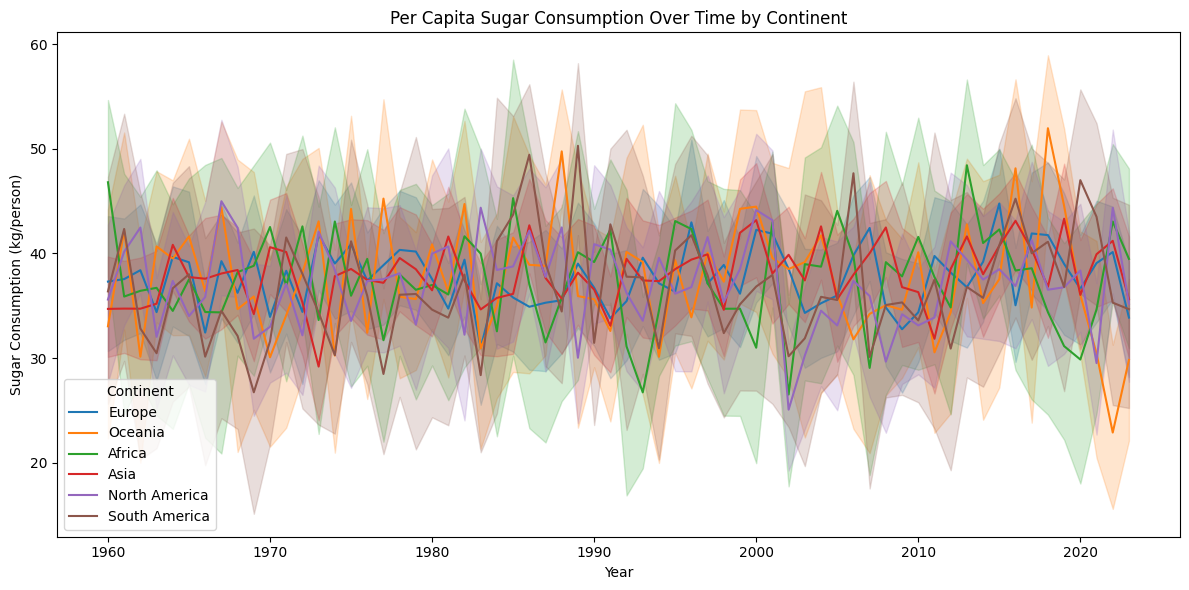

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Per_Capita_Sugar_Consumption', hue='Continent')
plt.title('Per Capita Sugar Consumption Over Time by Continent')
plt.xlabel('Year')
plt.ylabel('Sugar Consumption (kg/person)')
plt.legend(title='Continent')
plt.tight_layout()
plt.show()

In [14]:
import plotly.express as px

latest_year = df['Year'].max()
latest_df = df[df['Year'] == latest_year]

fig = px.choropleth(
    latest_df,
    locations='Country_Code',
    color='Per_Capita_Sugar_Consumption',
    hover_name='Country',
    color_continuous_scale='Reds',
    title=f'Sugar Consumption Per Capita by Country ({latest_year})'
)
fig.show()


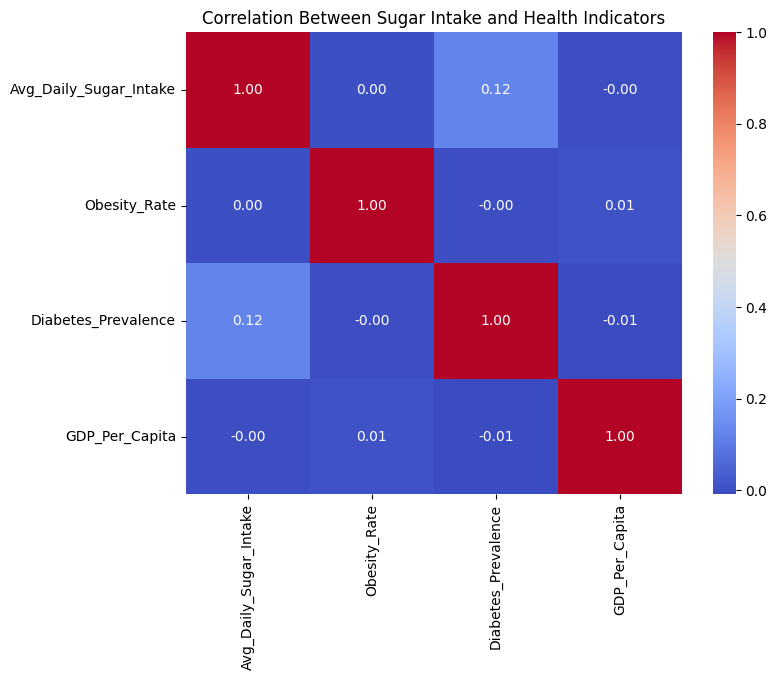

In [15]:
health_cols = ['Avg_Daily_Sugar_Intake', 'Obesity_Rate', 'Diabetes_Prevalence', 'GDP_Per_Capita']
corr = df[health_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Sugar Intake and Health Indicators')
plt.show()


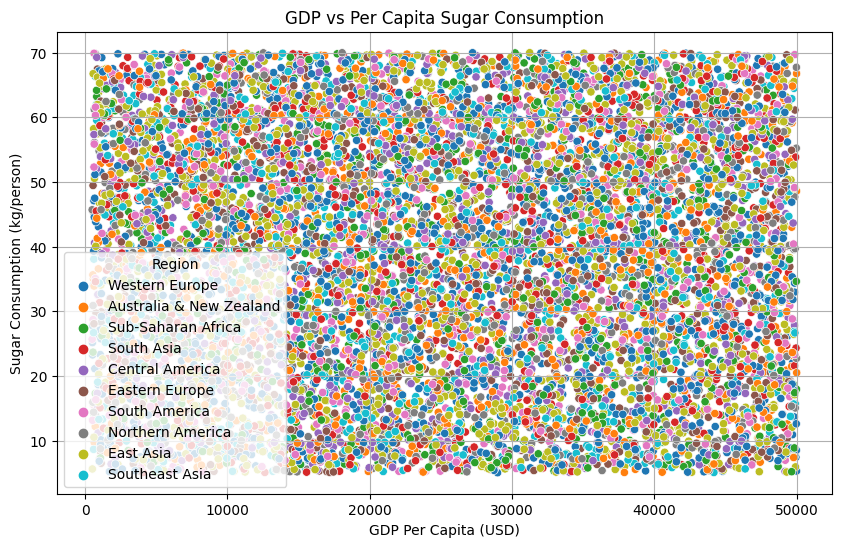

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GDP_Per_Capita', y='Per_Capita_Sugar_Consumption', hue='Region')
plt.title('GDP vs Per Capita Sugar Consumption')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Sugar Consumption (kg/person)')
plt.grid(True)
plt.show()


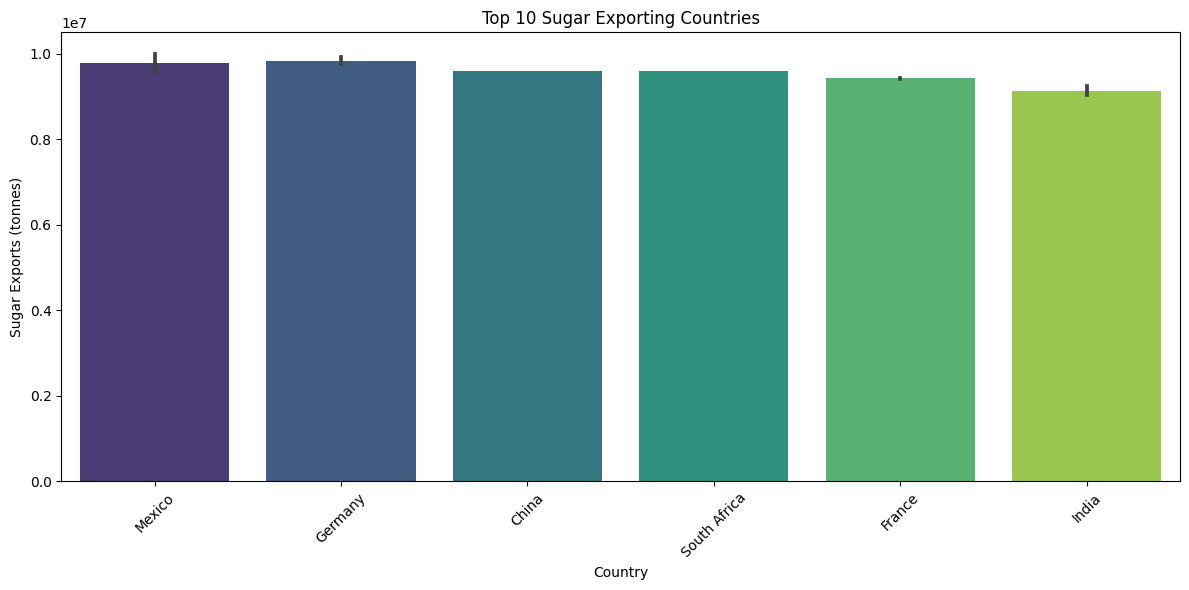

In [17]:
top_exporters = df[df['Year'] == latest_year].sort_values('Sugar_Exports', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_exporters, x='Country', y='Sugar_Exports', palette='viridis')
plt.title('Top 10 Sugar Exporting Countries')
plt.xlabel('Country')
plt.ylabel('Sugar Exports (tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

In [19]:
# 3. Create binary target from Obesity Rate
df['Target'] = (df['Obesity_Rate'] > 25).astype(int)

In [20]:
# 4. Label Encode categorical columns
cat_cols = ['Country', 'Continent', 'Region', 'Country_Code', 'Climate_Conditions']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [21]:
# 5. Select Features (drop target + unused original column)
features = [col for col in df.columns if col not in ['Obesity_Rate', 'Target']]
X = df[features]
y = df['Target']

In [22]:
# 6. Impute Missing Values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [23]:
# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# 8. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


In [25]:
# 9. Train Models, Evaluate, Plot
results = []

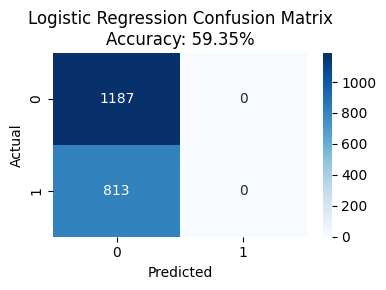

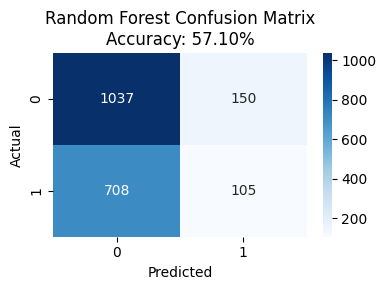

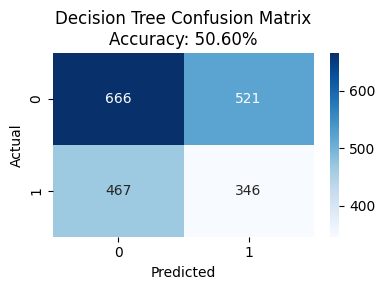

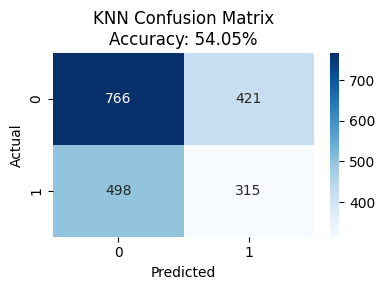

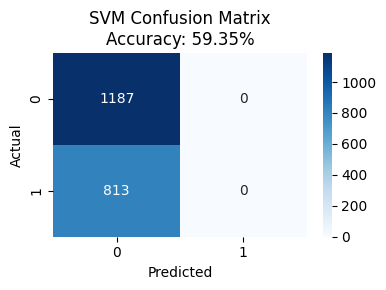

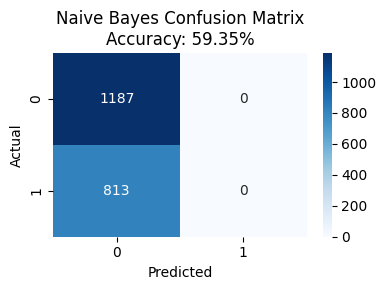

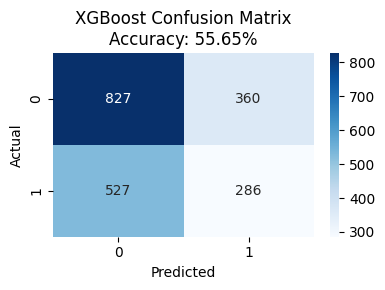

In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    results.append((name, acc))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix\nAccuracy: {acc:.2f}%')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


In [27]:
# 10. Show Accuracy Comparison
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy (%)'])
results_df = results_df.sort_values(by='Accuracy (%)', ascending=False)
print(results_df)

                 Model  Accuracy (%)
0  Logistic Regression         59.35
4                  SVM         59.35
5          Naive Bayes         59.35
1        Random Forest         57.10
6              XGBoost         55.65
3                  KNN         54.05
2        Decision Tree         50.60


## Thank you...pls upvote!!!